### Real-Time Violence Detection — CCTV Surveillance

## Background & Description

### What is this notebook?
This notebook trains and deploys a real-time anomaly detection system for CCTV footage. Using the **UCF Crime Dataset**, it classifies live video streams into four actionable categories:
- **Normal** — routine, uneventful activity
- **Theft** — shoplifting, robbery, burglary, stealing
- **Violence** — assault, fighting, abuse, shooting
- **Property damage** — arson, vandalism, and similar acts

---

### Key Definitions

**UCF Crime Dataset** — A large collection of real-world surveillance camera footage labeled with fine-grained crime categories, used here as the training data source.

**CLAHE (Contrast Limited Adaptive Histogram Equalization)** — An image processing technique that enhances local contrast. It operates in LAB colorspace to brighten dark CCTV footage without distorting colors.

**YOLOv8 (You Only Look Once)** — A fast object detection model used here to detect people and crop the frame tightly around them, focusing the model on human activity rather than background noise.

**Motion Frame Selection** — A technique that scores frames by pixel-level differences. The 16 frames with the highest motion scores are selected to capture the heart of the action within a window.

**ResNet50** — A deep convolutional network acting as a feature extractor. It converts a 224x224 image into a 2048-dimensional vector describing the visual content.

**BiLSTM (Bidirectional Long Short-Term Memory)** — A recurrent neural network that processes sequences forward and backward. It learns temporal patterns, like the specific motion signature of a physical altercation.

**Class Weights** — Mathematical multipliers applied during training to balance the dataset. They ensure the model pays extra attention to rare categories (like "Theft") instead of just defaulting to the most common label.

**L2 Regularization** — A penalty that prevents the model from becoming overly complex, forcing it to learn general patterns that work across different camera angles and lighting conditions.

**Dropout** — A technique that randomly deactivates neurons during training to prevent "memorization" and encourage the network to find robust, independent features.

**Temporal Smoothing** — A post-prediction filter that requires a label to maintain a consistent confidence score (e.g., >0.65) across multiple consecutive windows before triggering an alert.

---

### The Pipeline

#### 1. Data Preparation
- The dataset is filtered to the four target categories; irrelevant classes like `explosion` or `roadaccidents` are dropped.
- Class weights are calculated to compensate for the higher frequency of "Normal" videos.

#### 2. Frame Preprocessing
Every video passes through a standardized pipeline:
- **CLAHE** corrects for uneven surveillance lighting.
- **YOLOv8** crops the frame to the densest cluster of human activity with a 15-20% buffer for context.
- Frames are resized to 224x224 and converted to RGB.

#### 3. Motion-Based Sampling
- A 64-frame sliding window is sampled (matching the live inference buffer).
- The top 16 motion-heavy frames are extracted to eliminate static footage where no action is occurring.
- This process is repeated 5 times per video to augment the training data.

#### 4. Feature Extraction & Training
- Selected frames pass through **ResNet50** to create a (16, 2048) sequence.
- These sequences feed into the **BiLSTM** with dropout and L2 regularization.
- The model uses **Categorical Cross-Entropy** and **Early Stopping** to optimize for accuracy without overfitting.

#### 5. Live Inference & Thresholding
- **Rolling Buffer:** Frames are stored in a 64-frame deque. Every 8 frames, a snapshot is taken for analysis.
- **Daemon Threading:** Processing (YOLO + ResNet + BiLSTM) happens in a background thread to keep the video display fluid and real-time.
- **Smoothing & Voting:** Raw predictions must clear a confidence threshold. A **Majority Vote** across smoothed results determines the final classification for the entire clip.
  

In [1]:
!pip install mediapipe decord ultralytics -q
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

import os
import cv2
import pickle
import random
import threading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from tqdm.auto import tqdm
from IPython.display import Video, display
from collections import deque, Counter
import torch
import mediapipe as mp
from decord import VideoReader, cpu
from ultralytics import YOLO


print(f"TF  version : {tf.__version__}")
print(f"GPU (torch) : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name    : {torch.cuda.get_device_name(0)}")
print(f"TF GPUs     : {tf.config.list_physical_devices('GPU')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 83.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


2026-03-24 20:36:45.051971: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774384605.231589      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774384605.288343      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774384605.721922      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774384605.721968      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774384605.721971      55 computation_placer.cc:177] computation placer alr

TF  version : 2.19.0
GPU (torch) : True
GPU name    : Tesla P100-PCIE-16GB
TF GPUs     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
root_path = "/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/"

folder_list = os.listdir(root_path)
label_list  = [p for p in folder_list if not p.endswith(".csv")]

train_df  = pd.read_csv(root_path + 'train.csv')
test_df   = pd.read_csv(root_path + 'test.csv')

labels_df = pd.concat([train_df, test_df])[['label', 'video_name']]
labels_df

,label,video_name
0,normal,data\normal\Normal_Videos_196_x264.mp4
1,normal,data\normal\Normal_Videos179_x264.mp4
2,normal,data\normal\Normal_Videos361_x264.mp4
3,roadaccidents,data\roadaccidents\RoadAccidents017_x264.mp4
4,normal,data\normal\Normal_Videos125_x264.mp4
...,...,...
375,roadaccidents,data\roadaccidents\RoadAccidents025_x264.mp4
376,stealing,data\stealing\Stealing104_x264.mp4
377,stealing,data\stealing\Stealing036_x264.mp4
378,vandalism,data\vandalism\Vandalism045_x264.mp4


In [3]:
# Drop categories unrelated to surveillance threats
labels_df = labels_df[
    ~labels_df['label'].isin(['explosion', 'arrest', 'roadaccidents'])
].dropna().copy()

# Build full file paths
PREFIX = '/kaggle/input/real-time-anomaly-detection-in-cctv-surveillance/data/'
labels_df['video_name'] = (labels_df['video_name']
                           .str.replace('\\', '/', regex=False)
                           .str.split('/').str[-1])
labels_df['full_path'] = PREFIX + labels_df['label'] + '/' + labels_df['video_name']

# Collapse fine-grained labels → 4 categories
def label_mapping(lv):
    if lv in ['shoplifting', 'stealing', 'burglary', 'robbery']:
        return 'theft'
    if lv in ['abuse', 'assault', 'fighting', 'shooting']:
        return 'violence'
    if lv == 'normal':
        return 'normal'
    return 'property_damage'

labels_df['label'] = labels_df['label'].apply(label_mapping)
labels_df

,label,video_name,full_path
0,normal,Normal_Videos_196_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
1,normal,Normal_Videos179_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
2,normal,Normal_Videos361_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
4,normal,Normal_Videos125_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
5,normal,Normal_Videos160_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
...,...,...,...
374,property_damage,Arson049_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
376,theft,Stealing104_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
377,theft,Stealing036_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...
378,property_damage,Vandalism045_x264.mp4,/kaggle/input/real-time-anomaly-detection-in-c...


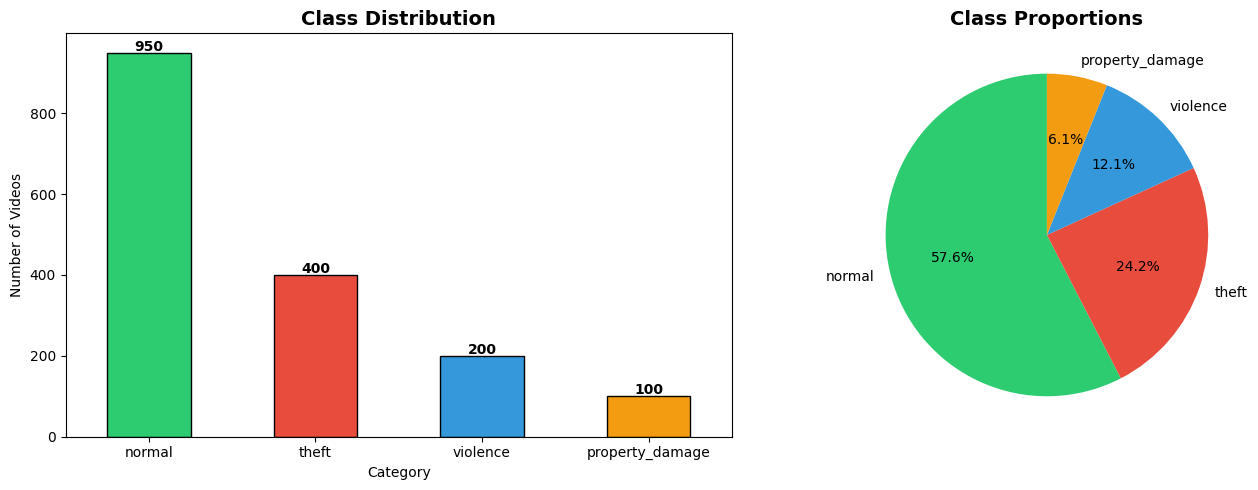

Total videos           : 1650
Class balance (min/max): 0.11


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = labels_df['label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Number of Videos')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout(); plt.show()
print(f"Total videos           : {len(labels_df)}")
print(f"Class balance (min/max): {counts.min()/counts.max():.2f}")

In [5]:
yolo_model = YOLO('yolov8n.pt')

def get_densest_cluster_coords(frame_shape, people_bboxes):
    """Return crop coords around the densest cluster of detected people."""
    bboxes  = np.array(people_bboxes)
    centers = bboxes[:, :2] + bboxes[:, 2:] / 2.0
    h_f, w_f = frame_shape[:2]
    threshold = 0.3 * np.sqrt(h_f**2 + w_f**2)
    diff = centers[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist_matrix = np.linalg.norm(diff, axis=2)
    densest_idx = np.argmax(np.sum(dist_matrix < threshold, axis=1))
    cluster = bboxes[dist_matrix[densest_idx] < threshold]
    x1 = np.min(cluster[:, 0]);  y1 = np.min(cluster[:, 1])
    x2 = np.max(cluster[:, 0] + cluster[:, 2])
    y2 = np.max(cluster[:, 1] + cluster[:, 3])
    pad = 0.15
    w_c, h_c = x2 - x1, y2 - y1
    return (int(max(0, x1 - w_c*pad)), int(max(0, y1 - h_c*pad)),
            int(min(w_f, x2 + w_c*pad)), int(min(h_f, y2 + h_c*pad)))

def crop_to_people(frame_bgr):
    """Crop frame to the region containing detected people."""
    results = yolo_model.predict(frame_bgr, classes=[0], conf=0.4, verbose=False, imgsz=640)[0]
    boxes = results.boxes.xywh.cpu().numpy()
    if len(boxes) == 0:
        return frame_bgr
    people_bboxes = [[b[0] - b[2]/2, b[1] - b[3]/2, b[2], b[3]] for b in boxes]
    if len(people_bboxes) == 1:
        x, y, w, h = people_bboxes[0]
        p = 0.2
        x1 = int(max(0, x - w*p));  y1 = int(max(0, y - h*p))
        x2 = int(min(frame_bgr.shape[1], x + w + w*p))
        y2 = int(min(frame_bgr.shape[0], y + h + h*p))
    else:
        x1, y1, x2, y2 = get_densest_cluster_coords(frame_bgr.shape, people_bboxes)
    cropped = frame_bgr[y1:y2, x1:x2]
    return cropped if cropped.size > 0 else frame_bgr

# ── CLAHE ─────────────────────────────────────────────────────────────────────
def apply_clahe(frame_bgr):
    """Boost local contrast in LAB colorspace."""
    lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

# ── Unified frame preprocessor — used identically in training AND live ─────────
def preprocess_frame(frame_bgr):
    """CLAHE → YOLOv8 person crop → resize 224×224 → RGB."""
    frame_bgr = apply_clahe(frame_bgr)
    frame_bgr = crop_to_people(frame_bgr)
    frame_bgr = cv2.resize(frame_bgr, (224, 224))
    return cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

print("YOLO + CLAHE utilities ready.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO + CLAHE utilities ready.


In [6]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("ResNet50 loaded. Output shape per frame: (2048,)")

I0000 00:00:1774384679.400937      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 loaded. Output shape per frame: (2048,)


In [7]:
def select_motion_from_array(frames, sequence_length=16):
    """
    Select the `sequence_length` highest-motion frames from a numpy array.
    frames : (N, H, W, 3) RGB numpy array
    Returns: (sequence_length, H, W, 3) numpy array
    """
    n = len(frames)
    if n <= sequence_length:
        result = list(frames)
        while len(result) < sequence_length:
            result.append(frames[-1])
        return np.array(result)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    t = torch.from_numpy(frames).float().to(device)
    gray = 0.299*t[:,:,:,0] + 0.587*t[:,:,:,1] + 0.114*t[:,:,:,2]
    scores = torch.sum(torch.abs(gray[1:] - gray[:-1]), dim=(1, 2)).cpu().numpy()

    top_rel = np.argsort(scores)[-sequence_length:]
    indices = sorted([int(i) + 1 for i in top_rel if int(i) + 1 < n])
    while len(indices) < sequence_length:
        indices.append(indices[-1] if indices else n - 1)

    return frames[indices[:sequence_length]]


def get_window_frames(video_path, window_size=64, sequence_length=16):
    """
    CHANGE 1 — Training-side window sampler.
    Sample a random `window_size`-frame window from the video, then select
    the top `sequence_length` motion frames within that window.
    This matches exactly what the live rolling buffer does at inference time.
    Returns: (sequence_length, H, W, 3) RGB numpy array, or None on failure.
    """
    try:
        vr    = VideoReader(video_path, ctx=cpu(0))
        total = len(vr)
        if total < 2:
            return None
        if total <= window_size:
            window_indices = list(range(total))
        else:
            start = random.randint(0, total - window_size)
            window_indices = list(range(start, start + window_size))
        frames = vr.get_batch(window_indices).asnumpy()   # RGB
        return select_motion_from_array(frames, sequence_length)
    except Exception as e:
        print(f'[window error] {video_path}: {e}')
        return None


print("Motion frame utilities ready.")

Motion frame utilities ready.


In [9]:
# Per-class window config — more windows for minority classes
CLASS_WINDOWS = {
    'normal':          5,
    'theft':           8,
    'violence':        12,
    'property_damage': 15,
}

WINDOW_SIZE = 64
SEQ_LEN     = 16

output_dir = '/kaggle/working/processed_motion_frames'
os.makedirs(output_dir, exist_ok=True)

# Delete existing pkl files so we re-extract with new window counts
# (comment this out if you want to only re-extract minority classes)
import shutil
shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

pbar = tqdm(labels_df.iterrows(), total=len(labels_df), desc="Extracting features")

for idx, row in pbar:
    video_path = row['full_path']
    video_name = row['video_name']
    label      = row['label']
    safe_name  = video_name.replace('.mp4', '.pkl')
    output_path = os.path.join(output_dir, safe_name)
    pbar.set_postfix(file=video_name[-22:], label=label)

    # Get the window count for this class
    n_windows = CLASS_WINDOWS[label]

    # Skip if already saved with correct number of windows
    if os.path.exists(output_path):
        with open(output_path, 'rb') as f:
            existing = pickle.load(f)
        if isinstance(existing, np.ndarray) and existing.ndim == 3 and existing.shape[0] == n_windows:
            continue

    all_features = []

    for _ in range(n_windows):
        raw_frames = get_window_frames(video_path, WINDOW_SIZE, SEQ_LEN)
        if raw_frames is None:
            continue

        processed = []
        for frame_rgb in raw_frames:
            frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
            rgb_224   = preprocess_frame(frame_bgr)
            processed.append(rgb_224)

        frames_array = np.array(processed, dtype='float32')
        features     = base_model.predict(
                           preprocess_input(frames_array), verbose=0)
        all_features.append(features)

    if all_features:
        with open(output_path, 'wb') as f:
            pickle.dump(np.array(all_features, dtype='float32'), f)

# Verification — show sample counts per class after extraction
print("\nExtraction complete. Verifying class distribution...\n")

class_counts = {k: 0 for k in CLASS_WINDOWS}
for idx, row in labels_df.iterrows():
    safe_name   = row['video_name'].replace('.mp4', '.pkl')
    output_path = os.path.join(output_dir, safe_name)
    if os.path.exists(output_path):
        with open(output_path, 'rb') as f:
            feat = pickle.load(f)
        class_counts[row['label']] += feat.shape[0]

print("Estimated training samples per class (before train/val/test split):")
for cls, count in class_counts.items():
    print(f"  {cls:20s}: {count} windows")

sample_file = os.path.join(output_dir, os.listdir(output_dir)[0])
sample_feat = pickle.load(open(sample_file, 'rb'))
print(f"\nSample file    : {os.path.basename(sample_file)}")
print(f"Shape          : {sample_feat.shape}")

Extracting features:   0%|          | 0/1650 [00:00<?, ?it/s]


Extraction complete. Verifying class distribution...

Estimated training samples per class (before train/val/test split):
  normal              : 4750 windows
  theft               : 3200 windows
  violence            : 2400 windows
  property_damage     : 1500 windows

Sample file    : Normal_Videos664_x264.pkl
Shape          : (5, 16, 2048)


In [10]:
# Manual class weights — more aggressive than sklearn balanced
class_weight_dict = {
    0: 0.3,   # normal          — heavily oversample, reduce its influence
    1: 0.8,   # theft
    2: 1.5,   # violence
    3: 3.0,   # property_damage — aggressively upweight
}

print("Manual class weights:")
for i, (label, weight) in enumerate(zip(['normal', 'theft', 'violence', 'property_damage'], class_weight_dict.values())):
    print(f"  {label:20s}: {weight}")

Manual class weights:
  normal              : 0.3
  theft               : 0.8
  violence            : 1.5
  property_damage     : 3.0


In [11]:
## 4. Build Dataset & Train / Val / Test Split

label2id = {'normal': 0, 'theft': 1, 'violence': 2, 'property_damage': 3}
id2label = {v: k for k, v in label2id.items()}

X, y = [], []
FEAT_DIR = '/kaggle/working/processed_motion_frames'

for idx, row in tqdm(labels_df.iterrows(), total=len(labels_df), desc="Loading features"):
    safe_name = row['video_name'].replace('.mp4', '.pkl')
    feat_path = os.path.join(FEAT_DIR, safe_name)
    if not os.path.exists(feat_path):
        continue
    with open(feat_path, 'rb') as f:
        feat = pickle.load(f)
    # Handle both new (N_WINDOWS, 16, 2048) and legacy (16, 2048) formats
    if feat.ndim == 2:
        feat = feat[np.newaxis, ...]
    for window_feat in feat:
        if window_feat.shape == (16, 2048):
            X.append(window_feat)
            y.append(label2id[row['label']])

X = np.array(X, dtype='float32')
y = np.array(y)

print(f"Dataset: X={X.shape}, y={y.shape}")
print(f"Samples per class: {dict(zip(*np.unique(y, return_counts=True)))}")

# Stratified 70 / 15 / 15 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

Loading features:   0%|          | 0/1650 [00:00<?, ?it/s]

Dataset: X=(11850, 16, 2048), y=(11850,)
Samples per class: {np.int64(0): np.int64(4750), np.int64(1): np.int64(3200), np.int64(2): np.int64(2400), np.int64(3): np.int64(1500)}
Train: 8295  Val: 1777  Test: 1778


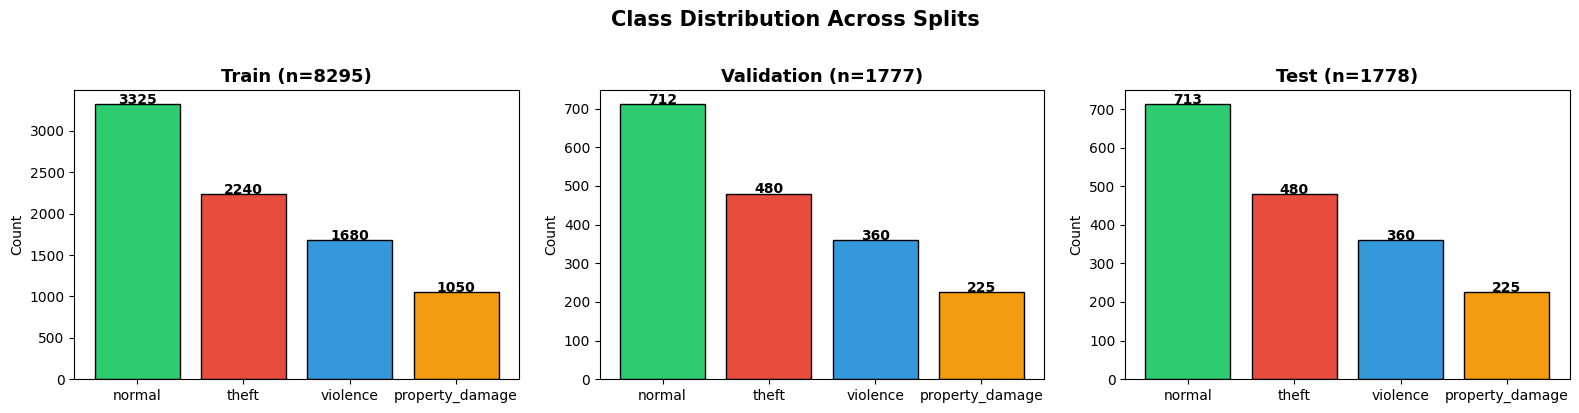

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
split_names  = ['Train', 'Validation', 'Test']
split_labels = [y_train, y_val, y_test]
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']

for ax, name, lbls in zip(axes, split_names, split_labels):
    unique, cnts = np.unique(lbls, return_counts=True)
    class_names  = [id2label[u] for u in unique]
    ax.bar(class_names, cnts, color=colors, edgecolor='black')
    ax.set_title(f'{name} (n={len(lbls)})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(cnts):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [15]:
## 5. BiLSTM Model — Build & Train

weights_arr = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights_arr))
print(f"Class weights: {class_weight_dict}")

def build_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(16, 2048)),
        layers.Bidirectional(layers.LSTM(64, dropout=0.5, return_sequences=True)),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(len(label2id), activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

import gc
gc.collect()
tf.keras.backend.clear_session()

lstm_model = build_model()
lstm_model.summary()

reduce_lr  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                          patience=3, min_lr=1e-6, verbose=1)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                      restore_best_weights=True)

class EpochLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}: "
                  f"loss={logs['loss']:.4f}  "
                  f"val_loss={logs['val_loss']:.4f}  "
                  f"val_acc={logs['val_accuracy']:.4f}")

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, EpochLogger()],
    verbose=0,
)

Class weights: {0: np.float64(0.6236842105263158), 1: np.float64(0.92578125), 2: np.float64(1.234375), 3: np.float64(1.975)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 16, 128)        │     1,081,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,090,372 (4.16 MB)

 Trainable params: 1,090,372 (4.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch  10: loss=1.0950  val_loss=1.0710  val_acc=0.6736
Epoch  20: loss=0.7179  val_loss=0.7110  val_acc=0.7929
Epoch  30: loss=0.5086  val_loss=0.5255  val_acc=0.8475
Epoch  40: loss=0.3711  val_loss=0.4371  val_acc=0.8779
Epoch  50: loss=0.3003  val_loss=0.3824  val_acc=0.8936

Epoch 53: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
Epoch  60: loss=0.2355  val_loss=0.3668  val_acc=0.9055

Epoch 61: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.

Epoch 64: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch  70: loss=0.2295  val_loss=0.3638  val_acc=0.9077
Epoch  80: loss=0.2245  val_loss=0.3625  val_acc=0.9077
Epoch  90: loss=0.2255  val_loss=0.3634  val_acc=0.9066


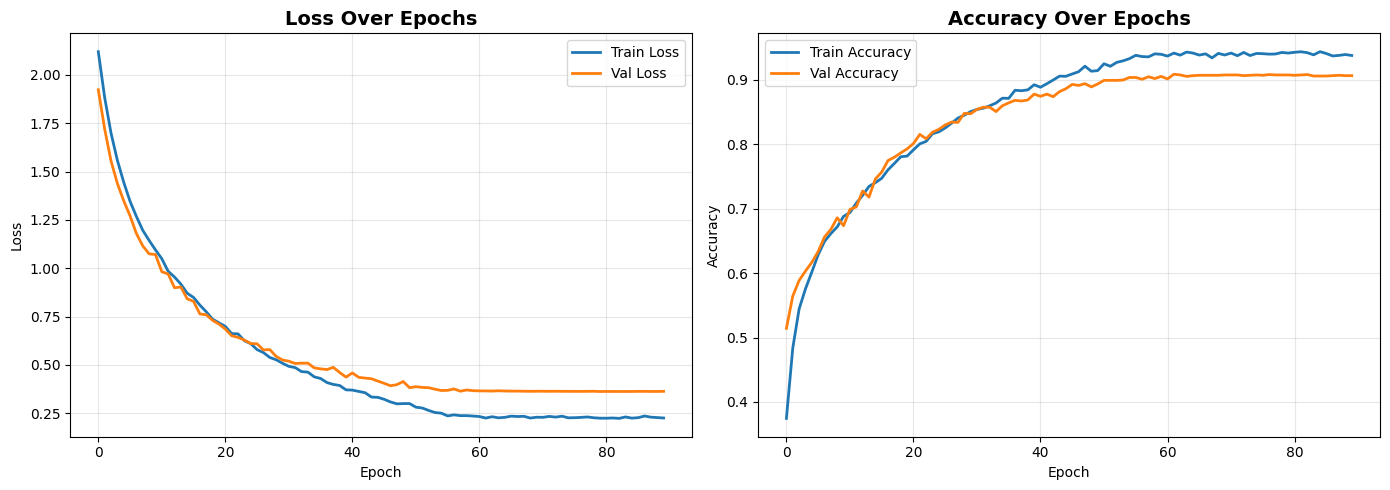

Best epoch    : 80
Val Loss      : 0.3625
Val Accuracy  : 0.9077


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[1].set_title('Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

best_epoch = np.argmin(history.history['val_loss'])
print(f"Best epoch    : {best_epoch + 1}")
print(f"Val Loss      : {history.history['val_loss'][best_epoch]:.4f}")
print(f"Val Accuracy  : {history.history['val_accuracy'][best_epoch]:.4f}")

In [17]:
## 6. Evaluation
eval_labels = ['normal', 'theft', 'violence', 'property_damage']

print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)

test_loss, test_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

y_pred_probs = lstm_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=eval_labels, digits=4))

TEST SET EVALUATION

Test Accuracy : 91.23%
Test Loss     : 0.3268

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

         normal     0.9602    0.9144    0.9368       713
          theft     0.8812    0.8812    0.8812       480
       violence     0.8709    0.9556    0.9113       360
property_damage     0.9062    0.9022    0.9042       225

       accuracy                         0.9123      1778
      macro avg     0.9047    0.9134    0.9084      1778
   weighted avg     0.9140    0.9123    0.9125      1778



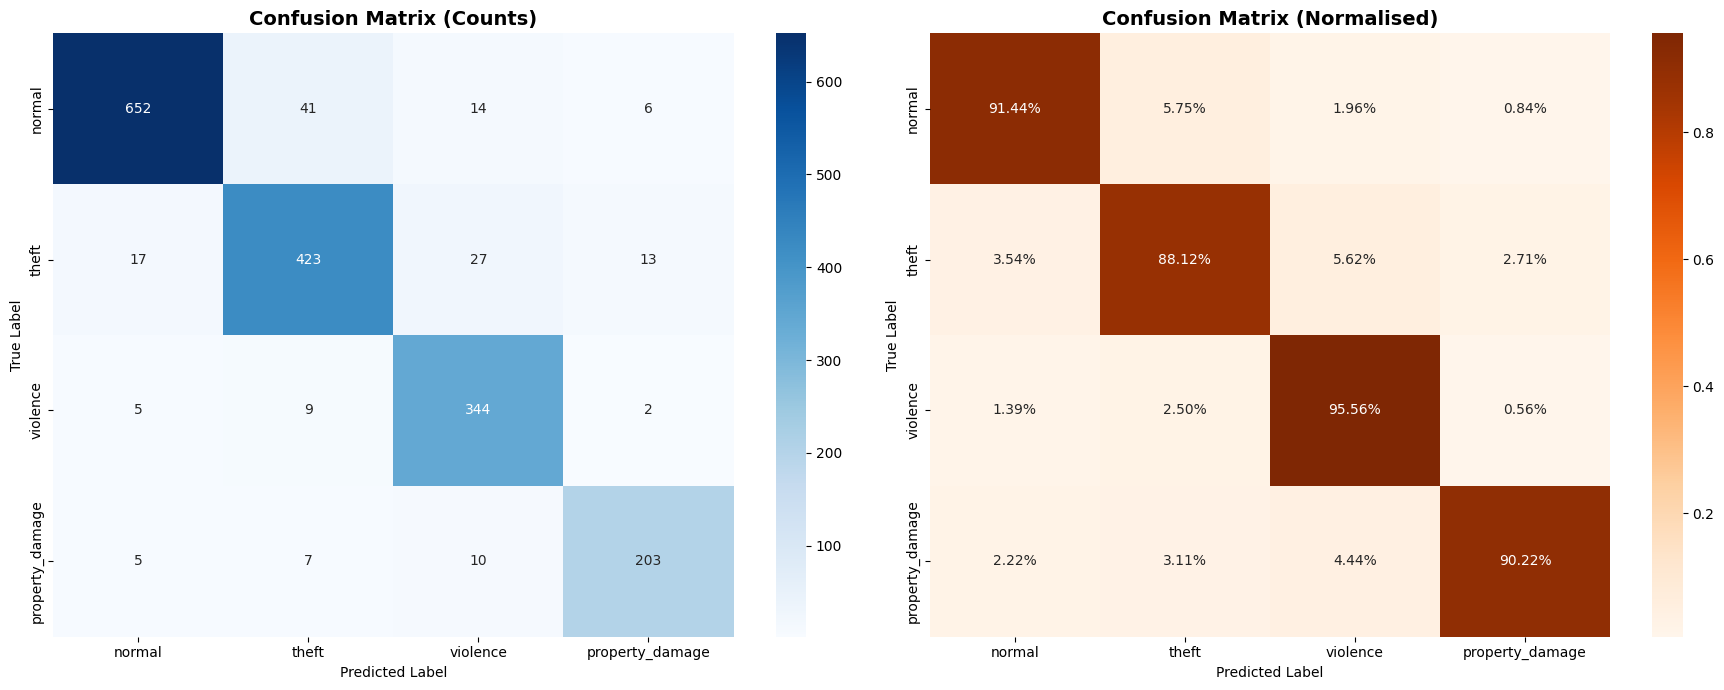

In [18]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=eval_labels, yticklabels=eval_labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)',     fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges',
            xticklabels=eval_labels, yticklabels=eval_labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')

plt.tight_layout(); plt.show()

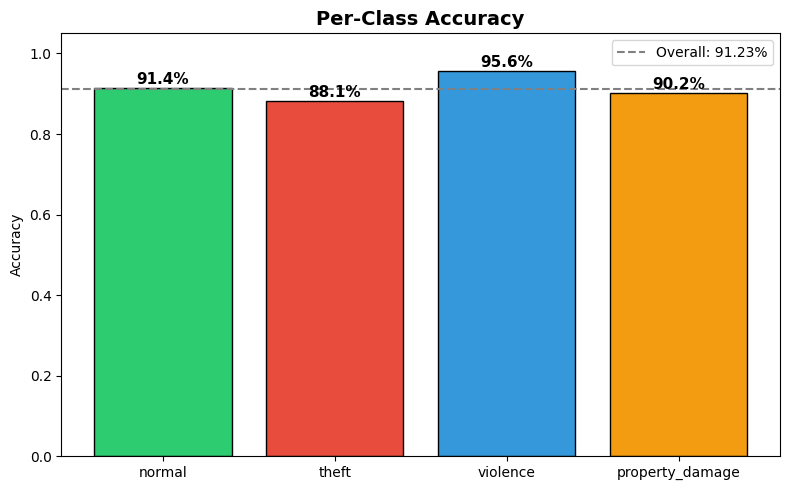

In [19]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(eval_labels, per_class_acc,
              color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'], edgecolor='black')
ax.axhline(y=test_acc, color='gray', linestyle='--',
           label=f'Overall: {test_acc:.2%}')
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.05); ax.legend()
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.1%}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

In [20]:
inv_label_map = {i: name for i, name in enumerate(eval_labels)}

print("=" * 70)
print("MISCLASSIFICATION ANALYSIS")
print("=" * 70 + "\n")

misclassified = np.where(y_test != y_pred)[0]
print(f"Total: {len(misclassified)} / {len(y_test)}\n")

pairs = {}
for i in misclassified:
    pair = (inv_label_map[int(y_test[i])], inv_label_map[int(y_pred[i])])
    pairs[pair] = pairs.get(pair, 0) + 1

for (true_l, pred_l), count in sorted(pairs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {true_l:18s} -> {pred_l:18s}: {count:3d}")

MISCLASSIFICATION ANALYSIS

Total: 156 / 1778

  normal             -> theft             :  41
  theft              -> violence          :  27
  theft              -> normal            :  17
  normal             -> violence          :  14
  theft              -> property_damage   :  13
  property_damage    -> violence          :  10
  violence           -> theft             :   9
  property_damage    -> theft             :   7
  normal             -> property_damage   :   6
  property_damage    -> normal            :   5
  violence           -> normal            :   5
  violence           -> property_damage   :   2


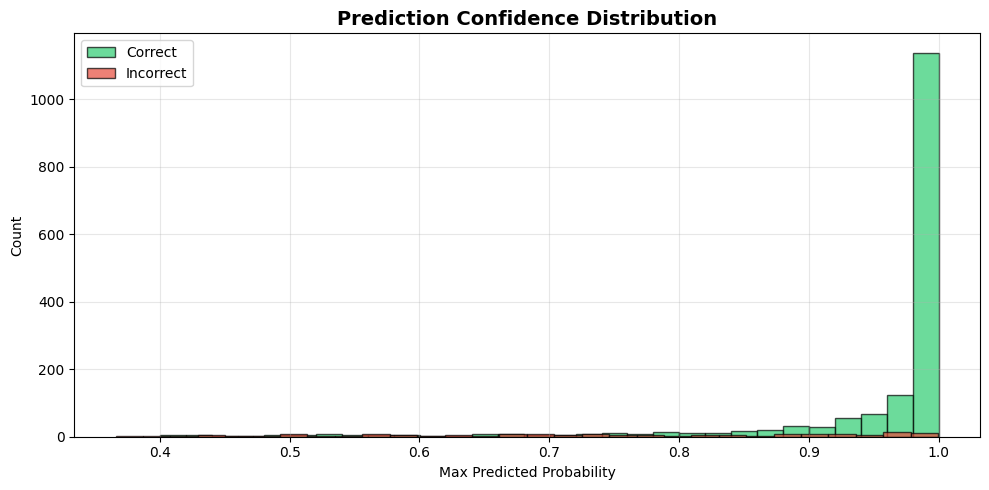

Mean confidence (correct)  : 0.9546
Mean confidence (incorrect): 0.7494


In [21]:
max_probs    = np.max(y_pred_probs, axis=1)
correct_mask = y_test == y_pred

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_probs[correct_mask],  bins=30, alpha=0.7,
        label='Correct',   color='#2ecc71', edgecolor='black')
ax.hist(max_probs[~correct_mask], bins=30, alpha=0.7,
        label='Incorrect', color='#e74c3c', edgecolor='black')
ax.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Max Predicted Probability'); ax.set_ylabel('Count')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Mean confidence (correct)  : {max_probs[correct_mask].mean():.4f}")
print(f"Mean confidence (incorrect): {max_probs[~correct_mask].mean():.4f}")

In [22]:
## 7. Live Inference — Changes 1, 2, 3 integrated

# ── Save trained models ────────────────────────────────────────────────────────
lstm_model.save('/kaggle/working/lstm_model.keras')
base_model.save('/kaggle/working/resnet50_extractor.keras')
print("Models saved.")

# ── Config ─────────────────────────────────────────────────────────────────────
BUFFER_SIZE          = 64    # rolling buffer size — must match WINDOW_SIZE in training
SEQUENCE_LENGTH      = 16    # motion frames selected per inference
INFER_EVERY_N        = 8     # run inference every N frames
CONFIDENCE_THRESHOLD = 0.65  # raised from 0.55 — reduces live false positives

# ── Shared state ───────────────────────────────────────────────────────────────
frame_buffer      = deque(maxlen=BUFFER_SIZE)
inference_state   = {'label': 'buffering...', 'conf': 0.0, 'lock': threading.Lock()}
predictions       = []

# CHANGE 3: rolling window for temporal smoothing
prediction_window = deque(maxlen=5)


# ── CHANGE 3: Temporal smoothing ───────────────────────────────────────────────
def get_smoothed_label(new_label, new_conf):
    """
    Maintain a rolling window of the last 5 predictions.
    Score each label by the sum of its confidence values across those 5 slots.
    The winning label must also clear an average-confidence threshold to be
    reported — otherwise 'uncertain' is returned.
    This prevents a single noisy window from triggering a false alert.
    """
    prediction_window.append((new_label, new_conf))

    scores = {}
    for label, conf in prediction_window:
        scores[label] = scores.get(label, 0.0) + conf

    best     = max(scores, key=scores.get)
    avg_conf = scores[best] / len(prediction_window)   # penalises labels that only appeared once

    return best if avg_conf >= CONFIDENCE_THRESHOLD else 'uncertain'


# ── Motion selection — wraps select_motion_from_array for the live buffer ──────
def select_motion_frames(buffer):
    """
    Select top SEQUENCE_LENGTH motion frames from the rolling deque.
    Uses the same select_motion_from_array as training — keeps distributions aligned.
    """
    frames = np.array(list(buffer))
    return select_motion_from_array(frames, SEQUENCE_LENGTH)


# ── CHANGE 2: Inference thread — never blocks frame capture ───────────────────
def run_inference(selected_rgb):
    """
    Full inference pipeline in a background daemon thread:
    RGB frames → CLAHE + YOLO crop → ResNet50 → BiLSTM → smoothing → store result.
    Only one thread runs at a time (enforced by the is_alive() check in run_live).
    """
    try:
        # Convert RGB → BGR for preprocess_frame, which expects BGR
        prepped = np.array(
            [preprocess_frame(cv2.cvtColor(f, cv2.COLOR_RGB2BGR))
             for f in selected_rgb],
            dtype='float32'
        )                                                              # (16, 224, 224, 3)

        features = base_model.predict(
            preprocess_input(prepped), verbose=0)[np.newaxis, ...]    # (1, 16, 2048)
        probs    = lstm_model.predict(features, verbose=0)[0]         # (4,)

        pred_id   = int(np.argmax(probs))
        conf      = float(probs[pred_id])
        raw_label = id2label[pred_id] if conf >= CONFIDENCE_THRESHOLD else 'uncertain'

        # CHANGE 3: smooth before committing
        smoothed = get_smoothed_label(raw_label, conf)

        with inference_state['lock']:
            inference_state['label'] = smoothed
            inference_state['conf']  = conf

        predictions.append(smoothed)

    except Exception as e:
        print(f'[inference error] {e}')


# ── CHANGE 2: Main live loop — non-blocking ────────────────────────────────────
def run_live(source=0):
    """
    Frame capture runs on the main thread continuously.
    Inference runs on a background thread — one at a time.
    If inference is still running when the next trigger fires, that trigger
    is skipped rather than queued — prevents thread pile-up.
    """
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise RuntimeError(f'Cannot open source: {source}')

    frame_buffer.clear()
    predictions.clear()
    prediction_window.clear()

    frame_count   = 0
    active_thread = None
    print("Processing...")

    while True:
        ret, bgr = cap.read()
        if not ret:
            break

        frame_count += 1
        # Store RGB (matches training format)
        frame_buffer.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

        # Spawn inference thread every INFER_EVERY_N frames, but only if:
        #   1. Buffer has enough frames
        #   2. No inference is currently running
        if (frame_count % INFER_EVERY_N == 0
                and len(frame_buffer) >= SEQUENCE_LENGTH
                and (active_thread is None or not active_thread.is_alive())):

            selected = select_motion_frames(frame_buffer)
            if selected is not None:
                # .copy() is critical — the buffer will change while the thread runs
                active_thread = threading.Thread(
                    target=run_inference,
                    args=(selected.copy(),),
                    daemon=True,
                )
                active_thread.start()

    # Wait for any in-flight inference before printing results
    if active_thread is not None and active_thread.is_alive():
        active_thread.join(timeout=15)

    cap.release()

    # ── Final results ──────────────────────────────────────────────────────────
    if predictions:
        counts = Counter(predictions)
        final  = counts.most_common(1)[0][0]
        total  = len(predictions)
        print("\n── RESULTS ───────────────────────────────────────")
        for label, count in counts.most_common():
            bar = '█' * int(count / total * 30)
            print(f"  {label:20s} {count:4d}/{total}  {bar}")
        print(f"\n  FINAL PREDICTION : {final.upper()}")
        print("──────────────────────────────────────────────────")
    else:
        print("No predictions made — video may be too short or below SEQUENCE_LENGTH frames.")


print("Live detection ready.")

Models saved.
Live detection ready.


In [33]:
# --- 1. MODEL INITIALIZATION ---
# Reloading the pre-trained weights for the detection pipeline
lstm_model = tf.keras.models.load_model('/kaggle/working/lstm_model.keras')
base_model = tf.keras.models.load_model('/kaggle/working/resnet50_extractor.keras')
yolo_model = YOLO('yolov8n.pt')

id2label = {0: 'normal', 1: 'theft', 2: 'violence', 3: 'property_damage'}

# --- 2. LIVE INFERENCE TEST (External Dataset: SCVD) ---
# This section tests the model's generalization on the SmartCity CCTV Violence Detection dataset.
# Since .avi files typically do not play in notebooks, we convert to .mp4 for visualization.

input_video = '/kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted/Test/Violence/t_v005_converted.avi'
display_video = '/kaggle/working/test_inference_display.mp4'

print(f"Checking for external video at: {input_video}")

if os.path.exists(input_video):
    # Convert for browser-compatible playback
    !ffmpeg -y -i {input_video} -vcodec libx264 -f mp4 {display_video} -loglevel quiet
    
    # Visual playback in notebook
    print("Playing converted video...")
    display(Video(display_video, embed=True, width=600))
    
    # Execute the live inference pipeline
    print("Running Live Detection Logic...")
    run_live(source=input_video)
else:
    print("Input file not found. Please check the dataset path.")

Checking for external video at: /kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted/Test/Normal/t_n001_converted.avi
Playing converted video...


Running Live Detection Logic...
Processing...

── RESULTS ───────────────────────────────────────
  normal                  1/1  ██████████████████████████████

  FINAL PREDICTION : NORMAL
──────────────────────────────────────────────────
